In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers, data_generation_gamma, contaminated_normal
from bayesian_dro.Bayesian_DRO_continuous import EPSILON_SET
from mis_dro.models import univariate_GaussianModel
from mis_dro.npl import Npl

/tmp/dcs-tmp.u1604520/ipykernel_192198/3046799791.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/"
experiment_dir_bdro = "/dcs/pg23/u1604520/misdro/results_kdro/"
# results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")
#results_other_dgps_df = pd.read_csv(experiment_dir / "results_patrick.csv", index_col="uuid")
#results_df = pd.concat([results_other_dgps_df, results_gamma_df])
dfs = []
# for dir in [experiment_dir, experiment_dir_bdro]:
for alg in ['mmd', 'bdro', 'kdro']: 
    for epsilon in EPSILON_SET:
        # if dir == experiment_dir:
        # if alg == 'kdro':
        if alg == 'kdro':
            dfs_k = []
            for i in range(5):
                if i == 0:
                    file_path = experiment_dir + f"{alg}_cont_exp_N900_ncert_200_cont_0.1_{epsilon}_fourier.csv"
                else:
                    file_path = experiment_dir + f"{alg}_cont_exp_N900_ncert_200_cont_0.1_{epsilon}_fourier_{i}.csv"
                df_ = pd.read_csv(file_path)
                dfs_k.append(df_)
            df = pd.concat(dfs_k, ignore_index=True)
            # file_path = experiment_dir + f"{alg}_cont_exp_N900_ncert_200_cont_0.1_{epsilon}_fourier.csv"
            # df = pd.read_csv(file_path)
        else:
            file_path = experiment_dir + f"{alg}_cont_exp_N900_ncert_200_cont_0.1_{epsilon}.csv"
            df = pd.read_csv(file_path)
            #f"kdro_cont_normal_N400_{epsilon}.csv"   #test_results_eps_{epsilon}.csv
        # else:
        # file_path = dir + f"bdro_exp_N100_ncert_20_{epsilon}.csv"
            # file_path = experiment_dir_bdro + f"{alg}_exp_N100_ncert_100_{epsilon}.csv"
        df['epsilon'] = epsilon
        # if dir == experiment_dir:
        # if alg == 'kdro':
        #     df['algorithm'] = 'mmd-dro'
        # else:
        #     df['algorithm'] = 'bdro'
        df['algorithm'] = alg
        dfs.append(df)
results_df = pd.concat(dfs, ignore_index=True)
# check the number of train/test observations is the same:
# assert len(results_df["num_observations"].unique()) == 1
# assert len(results_df["num_test_observations"].unique()) == 1
# num_observations = results_df["num_observations"]
# num_test_observations = results_df["num_test_observations"]
results_df

,replication,mean_cost,var_cost,solution,dgp_time,likelihood_time,posterior_time,solve_time,epsilon,algorithm
0,0,44.529908,291.857642,24.049427,0.000640,0.002265,0.000154,72.220441,0.001,mmd
1,1,33.567776,1976.138386,11.803390,0.001061,0.003830,0.000297,69.151099,0.001,mmd
2,2,35.516372,1754.208631,12.368985,0.000971,0.003784,0.000237,71.358836,0.001,mmd
3,3,46.305291,2852.393789,14.164905,0.000979,0.003773,0.000240,71.673502,0.001,mmd
4,4,45.919085,479.093719,23.340093,0.001123,0.003756,0.000229,70.373712,0.001,mmd
...,...,...,...,...,...,...,...,...,...,...
5395,15,226.075035,389.557044,84.859119,0.001848,0.008713,33.523780,3304.120827,3.000,kdro
5396,16,359.330138,578.769576,129.891264,0.001842,0.008799,33.508499,3313.189894,3.000,kdro
5397,17,226.296964,379.030654,83.347482,0.001876,0.008716,33.556859,3308.748732,3.000,kdro
5398,18,91.831697,581.903083,39.399568,0.001867,0.008806,33.567594,3311.471791,3.000,kdro


In [4]:
results_df = results_df[results_df['epsilon'] < 0.2]

In [5]:
gb = results_df.groupby(by=["algorithm", "epsilon"])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"]
})
df

mean_cost                 var_cost posterior_time  \
                        mean         var         mean           mean   
algorithm epsilon                                                      
bdro      0.001    45.406322  159.842765  1235.239765       0.000110   
          0.002    45.622457  156.144093  1215.134459       0.000110   
          0.005    46.384095  165.277441  1179.659560       0.000110   
          0.010    47.284362  177.419717  1138.669845       0.000110   
          0.020    48.645205  198.459790  1082.261630       0.000110   
          0.050    51.648340  241.866242   991.002920       0.000110   
          0.100    55.467415  312.766992   907.496517       0.000110   
          0.150    58.724169  378.519454   856.583397       0.000110   
kdro      0.001    39.015264   84.503609  1620.233303      36.892964   
          0.002    39.069818   84.383999  1611.542405      36.892964   
          0.005    39.198932   84.061784  1587.488817      36.892964   
          0.010    39.321779   83.630417  1557.389772      36.892964   
          0.020    39.552213   83.045894  1508.119395      36.892964   
          0.050    40.450599   81.471613  1380.559244      36.892964   
          0.100    42.191703   90.597496  1216.816252      36.892964   
          0.150    45.065520  117.362043  1040.622777      36.892964   
mmd       0.001    39.664974   82.832207  1475.441458       0.000221   
          0.002    39.763364   83.288958  1456.025230       0.000221   
          0.005    39.830772   83.320063  1456.006317       0.000221   
          0.010    39.862116   85.064337  1437.173764       0.000221   
          0.020    40.161208   87.411484  1389.334590       0.000221   
          0.050    41.109820   95.369355  1286.413888       0.000221   
          0.100    43.077817  109.116839  1138.107752       0.000221   
          0.150    45.984024  135.344042  1009.789298       0.000221   

                    solve_time   solution             
                          mean       mean        var  
algorithm epsilon                                     
bdro      0.001     701.682662  19.530800  36.680371  
          0.002     701.682662  19.713500  36.191092  
          0.005     701.682662  20.178200  38.020853  
          0.010     701.682662  20.717400  40.113751  
          0.020     701.682662  21.476600  43.437887  
          0.050     701.682662  23.049000  49.777177  
          0.100     701.682662  24.920900  58.567772  
          0.150     701.682662  26.410300  66.223225  
kdro      0.001    3277.036807  14.660542  14.543228  
          0.002    3277.036807  14.723699  14.757622  
          0.005    3277.036807  14.888054  15.065139  
          0.010    3277.036807  15.083906  15.414644  
          0.020    3277.036807  15.415204  16.054537  
          0.050    3277.036807  16.432804  18.575973  
          0.100    3277.036807  18.012278  23.415616  
          0.150    3277.036807  20.081048  29.362263  
mmd       0.001      69.613447  15.924125  16.242549  
          0.002      69.613447  16.002618  16.190916  
          0.005      69.613447  16.051023  16.683840  
          0.010      69.613447  16.139876  16.526239  
          0.020      69.613447  16.454754  17.016251  
          0.050      69.613447  17.291831  18.873203  
          0.100      69.613447  18.806334  22.070980  
          0.150      69.613447  20.663379  27.180698

In [6]:
def plot_dgp(df, dgp: str, axis, Nsamples):
    # get a dataframe for each posterior
    bayes_df = df.loc["bdro", :]
    kdro_df = df.loc['kdro', :]
    mmd_df = df.loc["mmd", :]

    # # mean of variances + variance of means
    bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    kdro_bootstrap_var = kdro_df["var_cost"]["mean"] + kdro_df["mean_cost"]["var"]
    mmd_bootstrap_var = mmd_df["var_cost"]["mean"] + mmd_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    axis.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="BDRO")
    axis.plot(kdro_bootstrap_var, kdro_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="BAS-DRO (MMD-NPL)")
    axis.plot(mmd_bootstrap_var, mmd_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="MMD-DRO")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}, {Nsamples} samples")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
        if i % 4 == 0:
            axis.text(bayes_bootstrap_var[epsilon], bayes_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        if (i+2) % 4 == 0:
            axis.text(mmd_bootstrap_var[epsilon], mmd_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

# plot mean-variance trade-off for each DGP
# dgp_list = list(df.index.get_level_values("dgp").unique())
# nrows = int(np.ceil(len(dgp_list)/2.0))
# fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=False, sharey=False, figsize=(10,10))
# for i, dgp in enumerate(dgp_list):
#     row = int(np.floor(i / 2.0))
#     col = i % 2
#     plot_dgp(dgp, axes[row][col])

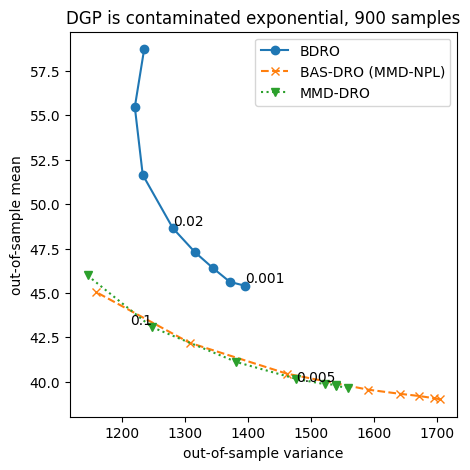

In [7]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
plot_dgp(df, 'contaminated exponential', axis, 900)

In [28]:
N = 20
contamination_level = 0.1
delta = 0.2
opt_epsilon = 4*contamination_level + 2*(np.sqrt(1/N) + np.sqrt((2*(N-1))/(N*(N+1))) + np.sqrt(2*N*np.log(1/delta))/N)
print(opt_epsilon)

2.251154811890592


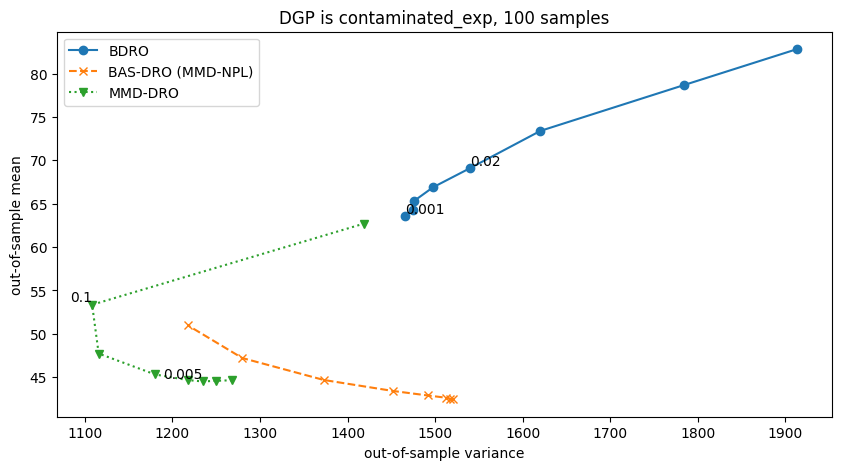

In [8]:
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/n100/"
experiment_dir_bdro = "/dcs/pg23/u1604520/misdro/results_kdro/n100/"
fig, axes = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(10,5))
N_values = [100] #, 400]
for i, N in enumerate(N_values):
    dfs = []
    for alg in ['bdro', 'kdro', 'mmd-dro']: #, 
        for epsilon in EPSILON_SET:
            if alg == 'bdro':
                file_path = experiment_dir_bdro + f"bdro_cont_exp_N100_ncert_200_cont_0.2_{epsilon}.csv" #f"kdro_cont_normal_N400_{epsilon}.csv"   #test_results_eps_{epsilon}.csv
            elif alg == 'kdro':
                file_path = experiment_dir + f"kdro_cont_exp_N100_ncert_200_cont_0.2_{epsilon}.csv"   # same exp just wrong file name
            else:
                file_path = experiment_dir + f"mmd_cont_exp_N{N}_ncert_200_cont_0.2_{epsilon}.csv" 
        
            df = pd.read_csv(file_path)
            df['epsilon'] = epsilon
            
            df['algorithm'] = alg
    
            dfs.append(df)
            
    results_df = pd.concat(dfs, ignore_index=True)
    results_df = results_df[results_df['epsilon'] < 0.2]
    gb = results_df.groupby(by=["algorithm", "epsilon"])
    df = gb.agg({
        "mean_cost": ["mean", "var"],
        "var_cost": ["mean"],
        "posterior_time": ["mean"],
        "solve_time": ["mean"],
        "solution": ["mean", "var"]
    })
    plot_dgp(df, 'contaminated_exp', axes, N)
plt.show()

In [7]:
from scipy.stats import truncnorm
b = 8
h = 3
L = 100

DGP_MEAN_TRUNCATED_NORMAL = 10
DGP_STD_TRUNCATED_NORMAL = 10

NUM_OBSERVATIONS = 20
sol_true = truncnorm.ppf(
        (b - 0) / (h + b), a=-DGP_MEAN_TRUNCATED_NORMAL / DGP_STD_TRUNCATED_NORMAL, b=np.inf, loc=DGP_MEAN_TRUNCATED_NORMAL, scale=DGP_STD_TRUNCATED_NORMAL
    )

In [8]:
sol_true

17.406341169581744

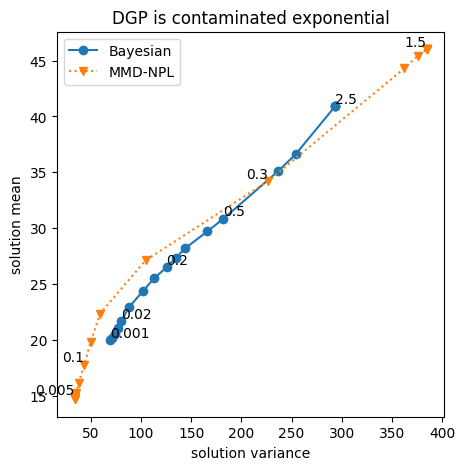

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
bayes_df = df.loc["bdro", :]
mmd_df = df.loc["mmd-dro", :]

bayes_bootstrap_var = bayes_df["solution"]["mean"] + bayes_df["solution"]["var"]
mmd_bootstrap_var = mmd_df["solution"]["mean"] + mmd_df["solution"]["var"]

# plot mean-variance trade-off
ax.plot(bayes_bootstrap_var, bayes_df["solution"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    # axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
ax.plot(mmd_bootstrap_var, mmd_df["solution"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

# set title and label epsilon
ax.set_title("DGP is contaminated exponential")
ax.legend()
ax.set_xlabel("solution variance")
ax.set_ylabel("solution mean")
for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
    if i % 4 == 0:
        ax.text(bayes_bootstrap_var[epsilon], bayes_df["solution"]["mean"][epsilon], epsilon, ha='left', va='bottom')
    if (i+2) % 4 == 0:
        ax.text(mmd_bootstrap_var[epsilon], mmd_df["solution"]["mean"][epsilon], epsilon, ha='right', va='bottom')

Number of certifying points 

In [21]:
n_cert_values = [5, 20, 100]
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/ncert/"
dfs = []
for ncert in n_cert_values:
    for epsilon in EPSILON_SET:
        file_path = experiment_dir + f"kdro_cont_exp_N25_ncert_{ncert}_{epsilon}.csv" 
        df = pd.read_csv(file_path)
        df['epsilon'] = epsilon
        df['ncert'] = ncert
        # df['algorithm'] = 'mmd-dro'
        dfs.append(df)
results_df = pd.concat(dfs, ignore_index=True)
gb = results_df.groupby(by=["epsilon", 'ncert'])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"]
})
df

mean_cost                  var_cost posterior_time solve_time  \
                    mean          var         mean           mean       mean   
epsilon ncert                                                                  
0.001   5      41.003834   117.784595  1684.199796      32.541000   2.560638   
        20     41.238288   119.066943  1659.759387      32.278920   3.545263   
        100    41.318634   121.590004  1664.658881      32.801849  12.112839   
0.002   5      41.087965   117.306235  1672.867524      32.541000   2.560638   
        20     41.341995   121.610721  1656.832544      32.278920   3.545263   
        100    41.253841   119.852579  1659.091641      32.801849  12.112839   
0.005   5      41.192305   118.274521  1667.173785      32.541000   2.560638   
        20     41.422357   123.410382  1648.386198      32.278920   3.545263   
        100    41.336741   123.153104  1646.557138      32.801849  12.112839   
0.010   5      41.315094   120.924640  1651.155711      32.541000   2.560638   
        20     41.469058   123.949111  1633.622204      32.278920   3.545263   
        100    41.490302   125.408508  1627.286672      32.801849  12.112839   
0.020   5      41.714913   129.062359  1616.897580      32.541000   2.560638   
        20     41.655643   126.858609  1602.229897      32.278920   3.545263   
        100    41.742262   129.800215  1597.677647      32.801849  12.112839   
0.050   5      42.559821   144.225159  1519.930139      32.541000   2.560638   
        20     42.569369   141.069328  1520.909913      32.278920   3.545263   
        100    42.565052   144.751434  1513.241599      32.801849  12.112839   
0.100   5      44.437862   172.916281  1360.640872      32.541000   2.560638   
        20     44.121180   167.007537  1369.685444      32.278920   3.545263   
        100    44.154849   172.136849  1378.075904      32.801849  12.112839   
0.150   5      46.485514   221.810500  1242.751313      32.541000   2.560638   
        20     46.236259   211.297205  1244.325284      32.278920   3.545263   
        100    46.178371   213.678389  1256.521160      32.801849  12.112839   
0.200   5      50.372133   359.161230  1138.652296      32.541000   2.560638   
        20     48.823084   281.847149  1140.893070      32.278920   3.545263   
        100    48.633531   276.149477  1148.505206      32.801849  12.112839   
0.250   5      56.224584   621.433110  1022.402205      32.541000   2.560638   
        20     53.573467   478.986419  1046.847907      32.278920   3.545263   
        100    53.191598   450.281700  1045.892101      32.801849  12.112839   
0.300   5      69.199087  1480.577010   928.791549      32.541000   2.560638   
        20     65.210128  1096.601938   938.451080      32.278920   3.545263   
        100    62.760862   928.822934   934.661291      32.801849  12.112839   
0.400   5      77.222372  2028.784376   863.998834      32.541000   2.560638   
        20     76.191567  1937.636351   865.852057      32.278920   3.545263   
        100    75.465720  1837.984410   866.378494      32.801849  12.112839   
0.500   5      78.577871  2131.803885   855.303811      32.541000   2.560638   
        20     78.357900  2115.090425   857.421259      32.278920   3.545263   
        100    78.448960  2131.977418   858.489356      32.801849  12.112839   
1.000   5      78.761449  2179.258428   866.712358      32.541000   2.560638   
        20     78.761449  2179.258618   866.712359      32.278920   3.545263   
        100    78.761450  2179.258606   866.712360      32.801849  12.112839   
1.500   5      78.761444  2179.257768   866.712356      32.541000   2.560638   
        20     78.761449  2179.258621   866.712358      32.278920   3.545263   
        100    78.761450  2179.258626   866.712357      32.801849  12.112839   
2.000   5      78.761449  2179.258561   866.712359      32.541000   2.560638   
        20     78.761449  2179.258609   866.712357      32.278920   3.545263   
        100    

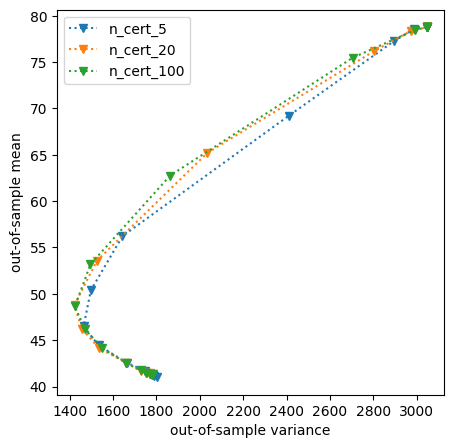

In [22]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
for ncert in n_cert_values:
   dfn = df.xs(ncert, level='ncert')
   var = dfn["var_cost"]["mean"] + dfn["mean_cost"]["var"]
   axis.plot(var, dfn["mean_cost"]["mean"], marker="v", linestyle="dotted", label=f"n_cert_{ncert}")
axis.legend()
axis.set_xlabel("out-of-sample variance")
axis.set_ylabel("out-of-sample mean")

plt.show()

Tolerance level

In [11]:
def calculate_opt_tol(num_observations, kernel_bound, concentration_param, delta, inf_mmd):
    N = num_observations
    M = kernel_bound
    a = concentration_param 
    first_term = np.sqrt(M/N) 
    second_term = np.sqrt((2*M*(N-1)+ a*(a+1))/((a+N)*(a+N+1)))
    third_term = np.sqrt((M*a*(a+1))/((a+N)*(a+N+1)))
    fourth_term = np.sqrt(2*N*M*np.log(1/delta))/(a+N)
    return 2*(first_term+second_term+third_term+fourth_term) + inf_mmd

In [21]:
print(calculate_opt_tol(20,1,0,0.2,0))

1.851154811890592


### New

In [3]:
experiment_dir = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N20_cont_mvn_known_cov")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
# for _, row in results_df.iterrows():
#     if row["algorithm"] == "kl_bdro":
#         num_total_samples.append(row["num_likelihood_samples"] ** 2)
#     elif row["algorithm"] == "kl_dro_bas":
#         num_total_samples.append(row["num_likelihood_samples"])
# results_df["num_total_samples"] = num_total_samples

# NOTE filter by DGP
results_df = results_df.loc[results_df["dgp"] == "multivariate_normal"]   #contaminated_exp contaminated_normal
results_df = results_df[results_df['epsilon'] < 0.3]
results_df

mean_cost     var_cost  \
uuid                                 replication                           
fd40d26f-b07e-4aa4-9d49-382935245a8c 0            42.388188   802.360956   
                                     1            42.479546   699.327443   
                                     2            41.573402   831.586679   
                                     3            39.582951   821.911450   
                                     4            37.279431   677.629410   
...                                                     ...          ...   
83b7ba8d-b4e8-4be6-abed-bf593de29539 195          50.511393   996.793123   
                                     196          53.573246  1016.009870   
                                     197          49.696435  1044.762513   
                                     198          59.186204  1246.334065   
                                     199          54.785988  1082.533766   

                                                                                           solution  \
uuid                                 replication                                                      
fd40d26f-b07e-4aa4-9d49-382935245a8c 0            [16.907565867771318, 31.231750008046358, 41.34...   
                                     1            [24.90167798376768, 29.221971892981735, 36.790...   
                                     2            [26.092691650878283, 26.72946857619672, 40.653...   
                                     3            [17.263341752349522, 30.279969720939675, 42.36...   
                                     4            [21.52776534342384, 29.247803336163198, 42.223...   
...                                                                                             ...   
83b7ba8d-b4e8-4be6-abed-bf593de29539 195          [31.149376805976242, 36.84527792853108, 41.773...   
                                     196          [34.911225115076576, 37.50717543034883, 38.753...   
                                     197          [32.69604195525025, 36.75726722478529, 35.4962...   
                                     198          [37.627207950814395, 39.428104793282714, 40.49...   
                                     199          [37.21871006927626, 40.018810513846546, 39.044...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
fd40d26f-b07e-4aa4-9d49-382935245a8c 0            0.023663         0.010449   
                                     1            0.001423         0.008491   
                                     2            0.001583         0.009685   
                                     3            0.001761         0.009326   
                                     4            0.001406         0.007602   
...                                                    ...              ...   
83b7ba8d-b4e8-4be6-abed-bf593de29539 195          0.001115         0.000001   
                                     196          0.001250         0.000001   
                                     197          0.001367         0.000001   
                                     198          0.002244         0.000001   
                                     199          0.001439         0.000001   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
fd40d26f-b07e-4aa4-9d49-382935245a8c 0                 85.896076   72.601628   
                                     1                 65.422714   71.655287   
                                     2                 42.616664   71.381866   
                                     3                 42.086518   70.655571   
                                     4                 42.092618   72.523663   
...                                                          ...         ...   
83b7ba8d-b4e8-4be6-abed-bf593de29539 195             

In [4]:
gb = results_df.groupby(by=["algorithm", "epsilon", "inference"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    # "posterior_time": ["mean"],
    # "setup_time": ["mean"],
    # "solve_time": ["mean"],
    # "solution": ["mean", "var"],
})
agg_df

mean_cost                var_cost
                                      mean        var         mean
algorithm     epsilon inference                                   
dro_bas_mmd   0.001   npl_mmd    39.782337   5.406582   743.581845
              0.002   npl_mmd    40.110480   5.674777   739.506754
              0.005   npl_mmd    40.813971   6.223557   731.163691
              0.010   npl_mmd    41.237529   6.547955   729.631163
              0.020   npl_mmd    41.717228   6.551840   727.459030
              0.030   npl_mmd    42.167956   7.059997   726.194184
              0.040   npl_mmd    42.717360   7.821730   724.610235
              0.050   npl_mmd    43.569732   9.073888   727.729049
              0.060   npl_mmd    44.431624  10.294315   733.706190
              0.070   npl_mmd    45.592074  12.205145   740.321397
              0.080   npl_mmd    46.843340  13.398196   753.713063
              0.090   npl_mmd    48.117361  14.510114   768.157461
              0.100   npl_mmd    49.434023  15.315168   783.532307
              0.150   npl_mmd    55.465778  24.442019   866.825352
              0.200   npl_mmd    58.852859  37.825557   931.785706
              0.250   npl_mmd    60.739313  45.481969   990.490047
empirical_mmd 0.001   empirical  38.910412   5.120934   814.541483
              0.002   empirical  38.934348   5.310774   810.326263
              0.005   empirical  39.009271   5.161258   803.657986
              0.010   empirical  39.099840   5.533506   791.133577
              0.020   empirical  39.547672   6.234537   762.137047
              0.030   empirical  40.147970   7.614546   759.594525
              0.040   empirical  40.829192   8.827021   750.762343
              0.050   empirical  41.479314  10.199030   747.936516
              0.060   empirical  42.160761  11.620772   745.975837
              0.070   empirical  42.913518  13.075079   754.104577
              0.080   empirical  43.595213  14.088794   760.978094
              0.090   empirical  44.182674  15.537718   770.821984
              0.100   empirical  44.901117  14.739918   782.353645
              0.150   empirical  47.864633  23.501500   851.747762
              0.200   empirical  50.485451  35.639949   948.286936
              0.250   empirical  52.138940  40.696714  1037.631822

In [5]:
def plot_dgp(df, dgp: str, axis, Nsamples):
    # get a dataframe for each posterior
    # bayes_df = df.loc["bdro", :]
    bas_df = df.loc['dro_bas_mmd', :]
    empirical_df = df.loc["empirical_mmd", :]

    # # mean of variances + variance of means
    # bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    bas_bootstrap_var = bas_df["var_cost"]["mean"] + bas_df["mean_cost"]["var"]
    empirical_bootstrap_var = empirical_df["var_cost"]["mean"] + empirical_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    # axis.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="BDRO")
    axis.plot(bas_bootstrap_var, bas_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="BAS-DRO (MMD-NPL)")
    axis.plot(empirical_bootstrap_var, empirical_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="Empirical-MMD-DRO")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}, {Nsamples} samples")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    for i, epsilon in enumerate(empirical_df.index.get_level_values("epsilon")):
        if i % 4 == 0:
            axis.text(bas_bootstrap_var[epsilon], bas_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        if (i+2) % 4 == 0:
            axis.text(empirical_bootstrap_var[epsilon], empirical_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

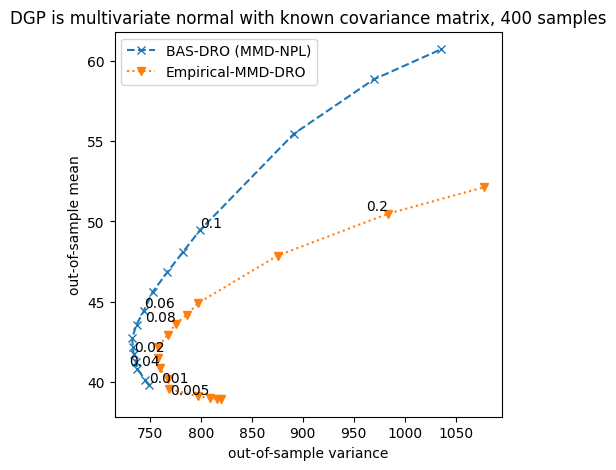

In [7]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
plot_dgp(agg_df, 'multivariate normal with known covariance matrix', axis, 400)